# Plot effective noise angle

This notebook utilizes the functions defined in directionality_core to plot various approximations of an effective noise angle for the Pylos operating conditions

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import sys
sys.path.append('../..')
import report_plotstyle

import matplotlib.colors as colors
norm = colors.Normalize(vmin=39, vmax=75) # 60

from directionality_core import *

In [2]:
# =====================================================
# Define parameter ranges
# =====================================================
theta_deg   = np.linspace(0, 90, 90)           # angle resolution
f_Hz_range  = np.geomspace(1e3, 25e3, 100)     # frequencies to scan 
z_m_range   = np.linspace(1000, 4000, 100)     # depths to scan      

# =====================================================
# Prepare storage
# =====================================================
theta_const_map         = np.zeros((len(z_m_range), len(f_Hz_range)))
theta_const_Cf          = np.zeros((len(z_m_range), len(f_Hz_range)))
theta_const_fullf_map   = np.zeros((len(z_m_range), len(f_Hz_range)))
theta_const_fullf_Cf    = np.zeros((len(z_m_range), len(f_Hz_range)))

theta_halfint_map       = np.zeros((len(z_m_range), len(f_Hz_range)))
theta_HW_map            = np.zeros((len(z_m_range), len(f_Hz_range)))
theta_HW_hydro_map      = np.zeros((len(z_m_range), len(f_Hz_range)))
theta_HW_hydro_vals     = np.zeros((len(z_m_range), len(f_Hz_range)))

# =====================================================
# Progress bar
# =====================================================
total = len(z_m_range) * len(f_Hz_range)
def update_progress(current, total, bar_length=20):
    progress = current / total
    filled_len = int(bar_length * progress)
    bar = "|" + "*" * filled_len + " " * (bar_length - filled_len) + "|"
    sys.stdout.write(f"\r{bar} {progress*100:.0f}%")
    sys.stdout.flush()

# =====================================================
# Main scan loop
# =====================================================
count = 0
for i, z in enumerate(z_m_range):
    for j, f in enumerate(f_Hz_range):
        # Compute F(theta)
        F_vals = np.array([Ftheta_attenuation(theta, z, f) for theta in theta_deg])

        # Find where F(theta) == 1
        theta_half_int, val         = compute_F1(theta_deg, F_vals)
        theta_halfint_map[i,j]      = theta_half_int

        # Compute haldwidth of F(theta)
        theta_HW_map[i, j]          = compute_half_width(theta_deg, F_vals)[0]

        # Compute halfwidth of F(theta)H(theta, f)
        theta_HW_hydro, HW_hydro, theta_max = compute_half_width_hydrophone(theta_deg, F_vals, f)
        theta_HW_hydro_map[i, j]    = theta_HW_hydro
        theta_HW_hydro_vals[i, j]   = HW_hydro
        
        roots, Cf                   = compute_const_hydrophone_res(theta_deg, F_vals)
        theta_const_Cf[i,j]         = Cf

        if len(roots) > 0:
            theta_const_map[i,j]    = roots[0]  # Take the first root if multiple

        # Compute where int(F(theta)H(theta) == C/2)
        roots_ffull, Cf_full       = compute_const_hydrophone_full(theta_deg, F_vals, f)
        theta_const_fullf_Cf[i,j]  = Cf_full

        if len(roots_ffull) > 0:
            theta_const_fullf_map[i,j] = roots_ffull[0]

        # Update progress
        count += 1
        update_progress(count, total)

print('\n')

|********************| 100%



# 1) PLOTs F($\theta$)H($\theta$)
## 1a) $H(\theta)$

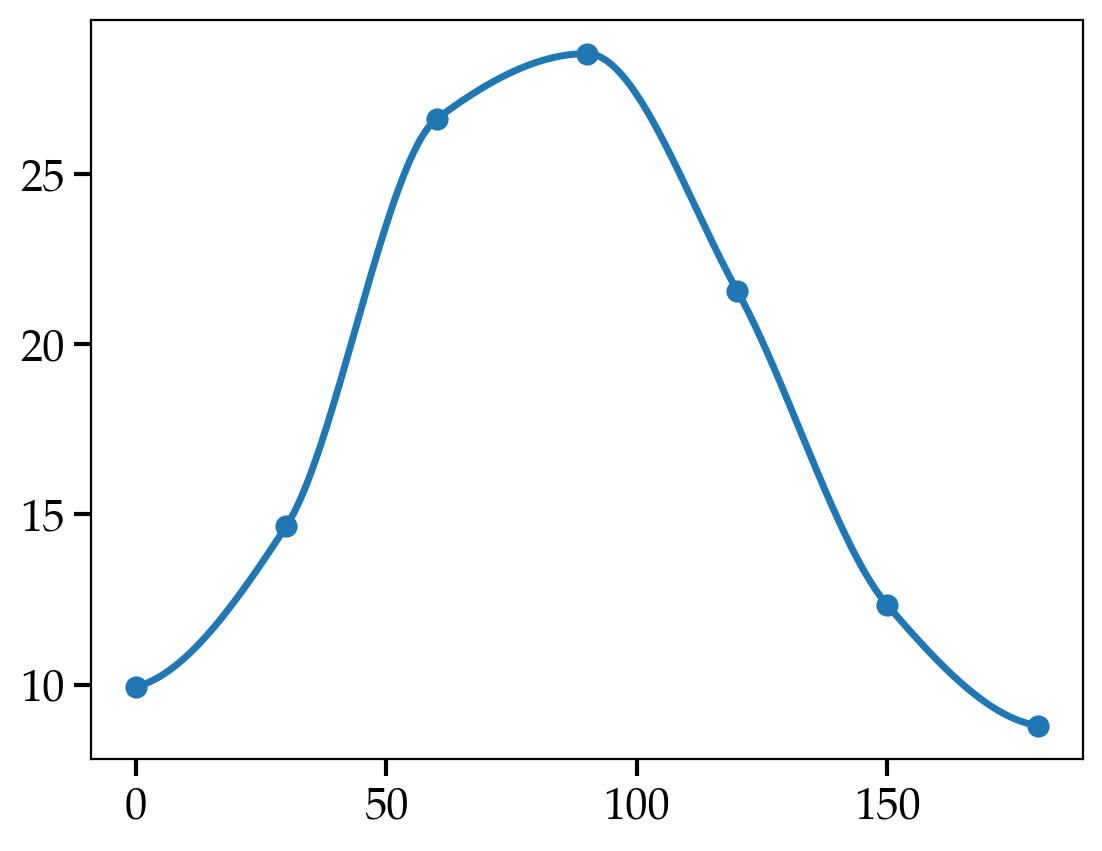

In [3]:
angls_fine = np.linspace(0, 180, 1000)

plt.figure()
plt.scatter(HYDROANGLESDEG, HYDRORESONANCEdB)
plt.plot(angls_fine, HYDRORESONANCEdBPCHIP(angls_fine))

## 1b) $H(\theta)F(\theta)$

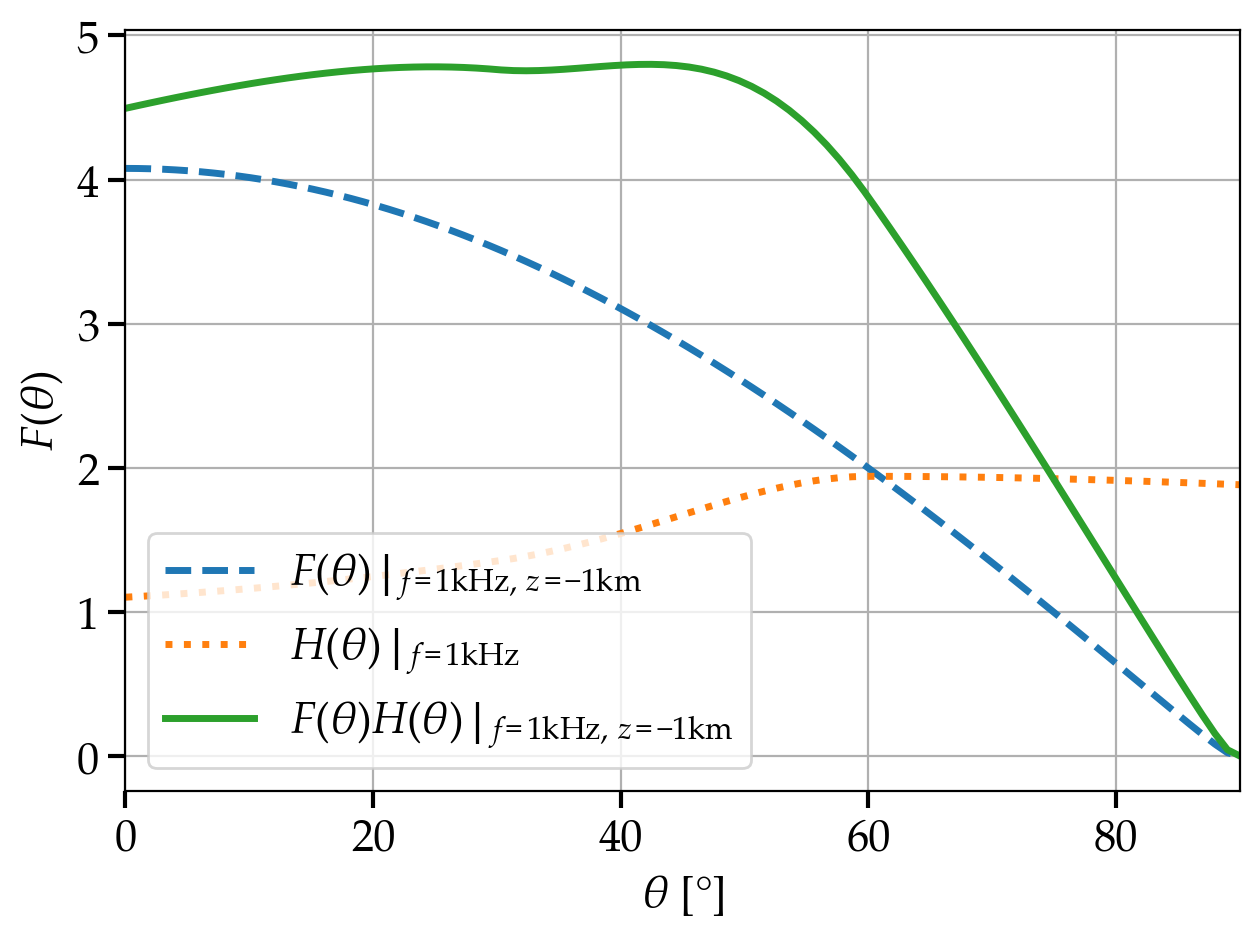

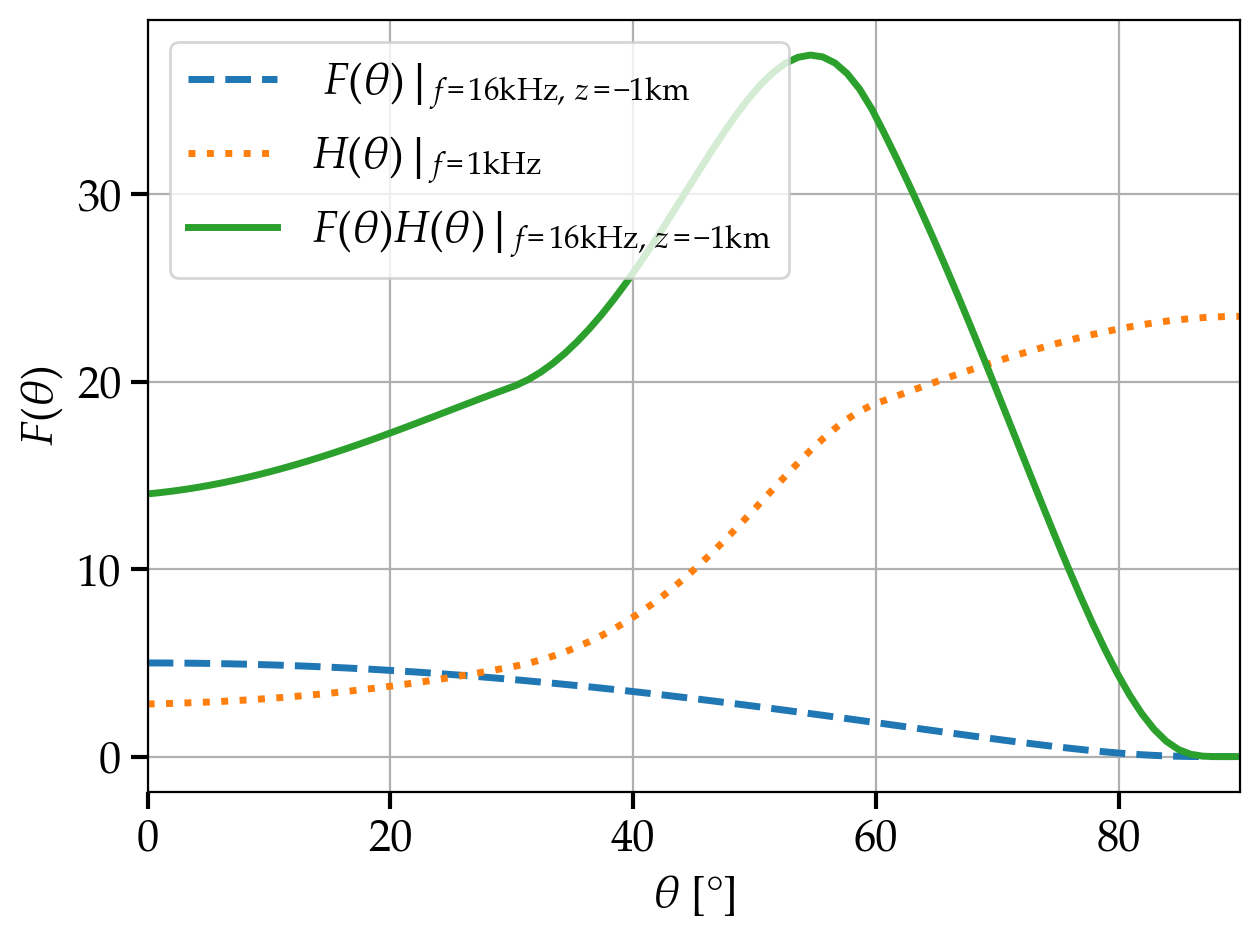

In [4]:
theta_deg = np.linspace(0, 90, 90)          # angle resolution
z         = 1e3

f1                = 1e3
F_vals_1k         = np.array([Ftheta_attenuation(theta, z, f1) for theta in theta_deg])
FthetaHtheta_1k   = F_vals_1k * hydrophone_response(theta_deg, f1)
Htheta_1k         = hydrophone_response(theta_deg, f1)

f2                = 16e3
F_vals_16k        = np.array([Ftheta_attenuation(theta, z, f2) for theta in theta_deg])
FthetaHtheta_16k  = F_vals_16k * hydrophone_response(theta_deg, f2)
Htheta_16k         = hydrophone_response(theta_deg, f2)

f3                = 25e3
F_vals_25k        = np.array([Ftheta_attenuation(theta, z, f3) for theta in theta_deg])
FthetaHtheta_25k  = F_vals_25k * hydrophone_response(theta_deg, f3)

plt.figure()
plt.plot(theta_deg, F_vals_1k,        ls= '--', label = r"$\left.F(\theta) \right| _{f = 1 \text{kHz}, \, z=-1 \text{km}}$")
plt.plot(theta_deg, Htheta_1k,        ls= ':',  label = r"$\left.H(\theta)\right| _{f = 1 \text{kHz}}$")
plt.plot(theta_deg, FthetaHtheta_1k,  ls= '-',  label = r"$\left.F(\theta)H(\theta) \right|_{f = 1 \text{kHz}, \, z=-1 \text{km}}$")
plt.xlabel(r"$\theta$ [°]")
plt.ylabel(r"$F(\theta)$")
plt.legend(loc='lower left')
plt.xlim(0, 90)
plt.grid()
plt.tight_layout()

plt.figure()
plt.plot(theta_deg, F_vals_16k,       ls= '--', label = r" $\left.F(\theta) \right| _{f = 16 \text{kHz}, \, z=-1 \text{km}}$")
plt.plot(theta_deg, Htheta_16k,       ls= ':',  label = r"$\left.H(\theta)\right| _{f = 1 \text{kHz}}$")
plt.plot(theta_deg, FthetaHtheta_16k, ls= '-',  label = r"$\left.F(\theta)H(\theta) \right|_{f = 16 \text{kHz}, \, z=-1 \text{km}}$")
plt.xlabel(r"$\theta$ [°]")
plt.ylabel(r"$F(\theta)$")
plt.legend(loc='upper left')
plt.xlim(0, 90)
plt.grid()
plt.tight_layout()

# 2) Plot effective noise angle


In [5]:
# Convert z and f to the Pylos specifications and the convention where z = 0 is the sea surface
z_m_plot  = -(z_m_range/1000)
f_Hz_plot = f_Hz_range/1000

## 2a) $\int F(\theta, f)H(\theta, f)d\theta == C/2$
This is the effective noise angle used in the report

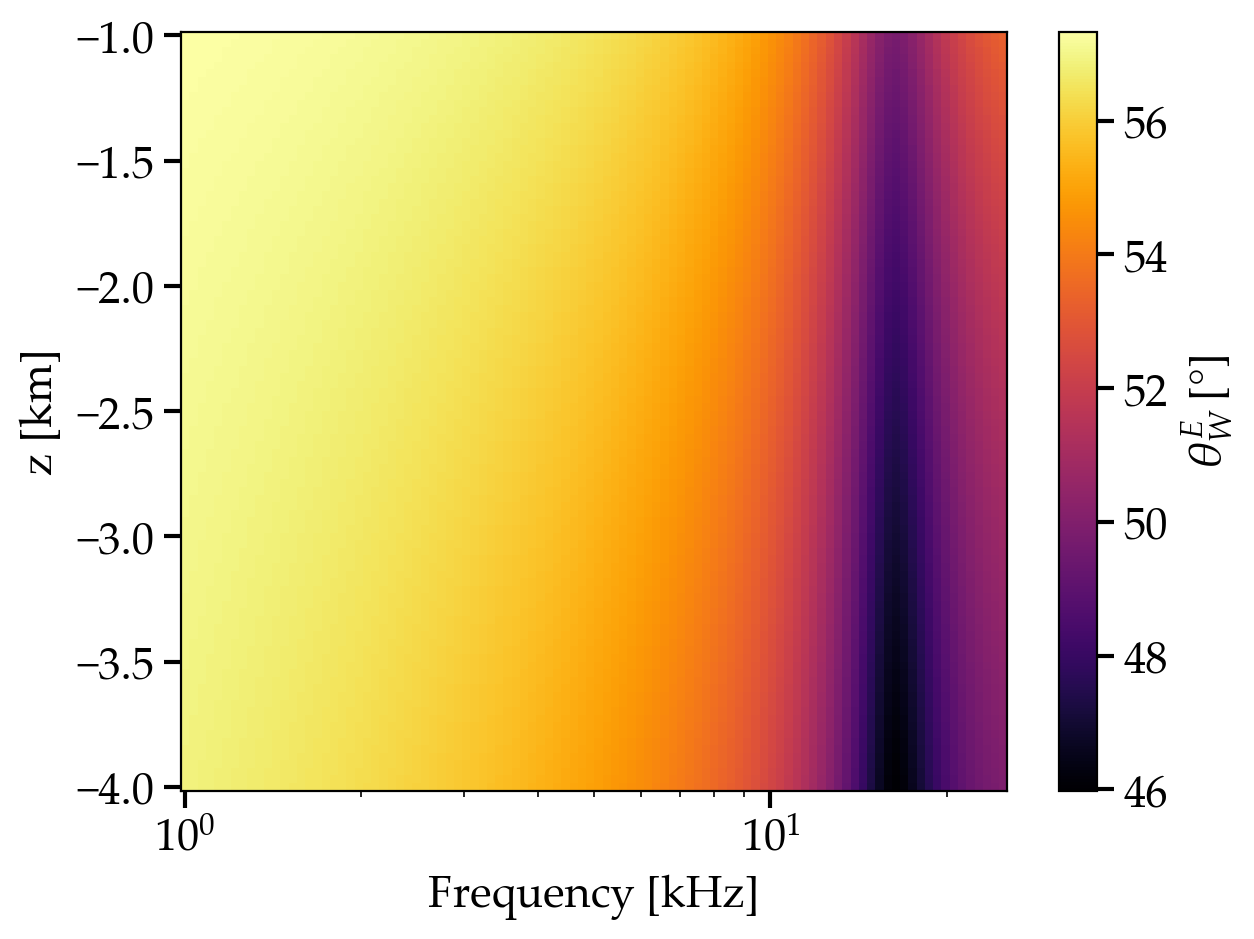

In [6]:
fig, ax = plt.subplots(1, 1, figsize=(6.4, 4.8))

# Plot the pcolormesh
im5 = ax.pcolormesh(f_Hz_plot, z_m_plot, theta_const_fullf_map,
                    shading='auto', cmap='inferno')

# Correct colorbar
cb5 = fig.colorbar(im5, ax=ax, label=r"$\theta_W^E$ [°]")

# Axis scaling and labels
ax.set_xscale('log')
ax.set_xlabel("Frequency [kHz]")
ax.set_ylabel(r"z [km]")
# ax.axvline(16)
# ax.set_title("Constant angle for full power, hydrophone normalised")

plt.tight_layout()
plt.show()

## 2b) $\int F(\theta, f_{res})H(\theta, f_{res})d\theta == C/2$
Simplification where at all frequencies and depths the directionality impact at the resonance frequency is used

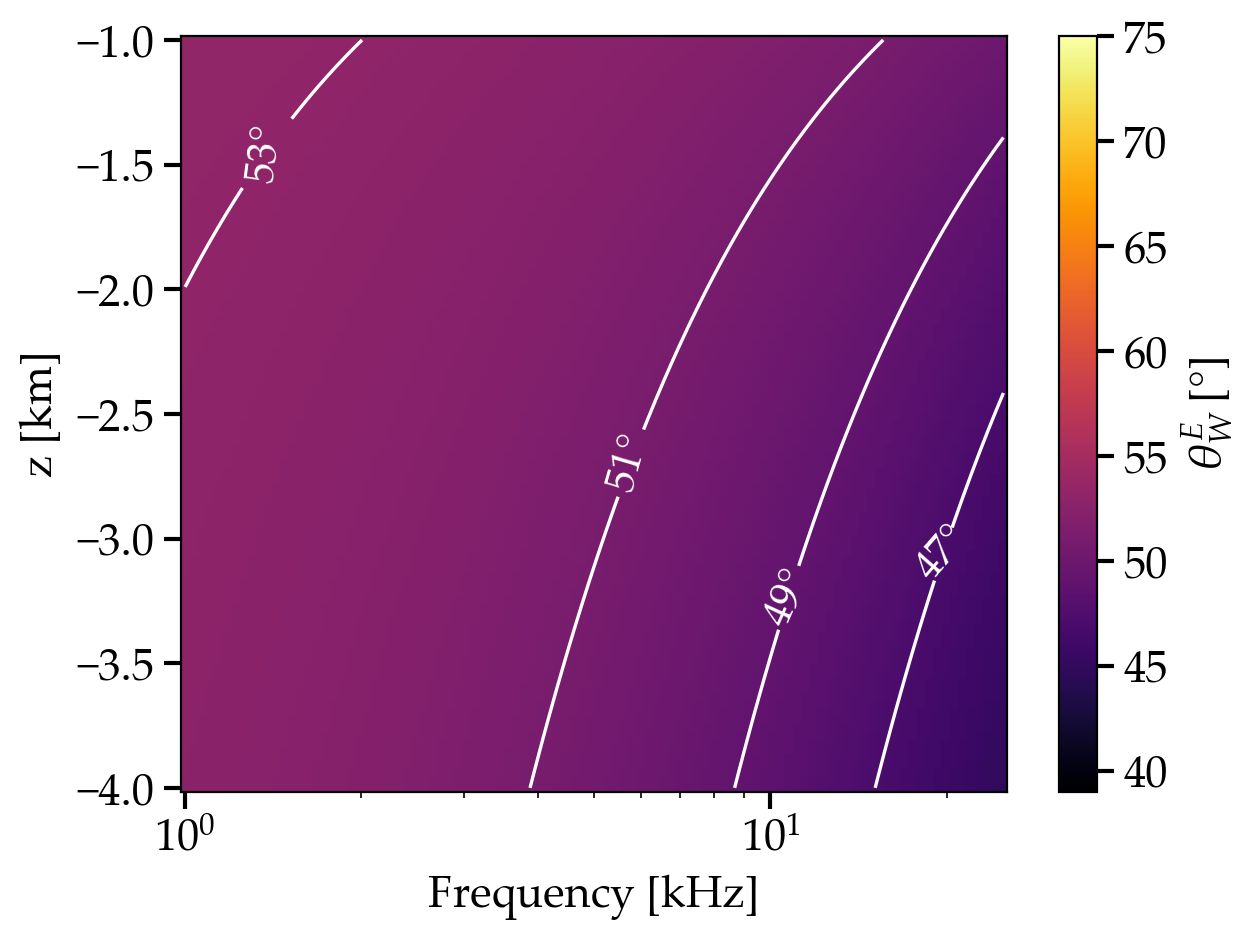

In [10]:
fig, ax = plt.subplots(1, 1, figsize=(6.4, 4.8))

# Plot the pcolormesh
im5 = ax.pcolormesh(f_Hz_plot, z_m_plot, theta_const_map,
                    shading='auto', cmap='inferno',norm=norm)

# Correct colorbar
cb5 = fig.colorbar(im5, ax=ax, label=r"$\theta_W^E$ [°]")

# Define and use contour levels consistently
levels_hydro_halfint = [47,49,51,53]
cs5 = ax.contour(f_Hz_plot, z_m_plot, theta_const_map,
                 levels=levels_hydro_halfint, colors='white', linewidths=1.2)

ax.clabel(cs5, inline=True, fontsize=15, fmt='%1.0f°')

# Axis scaling and labels
ax.set_xscale('log')
ax.set_xlabel("Frequency [kHz]")
ax.set_ylabel(r"z [km]")
# ax.set_title("Constant angle for full power, hydrophone normalised")

plt.tight_layout()
plt.show()

## 2c) $F(\theta_{HW}) = F(\theta = 0) / 2$
Half-width angle as used by Buckingham. Note that this excludes the hydrophone directionality

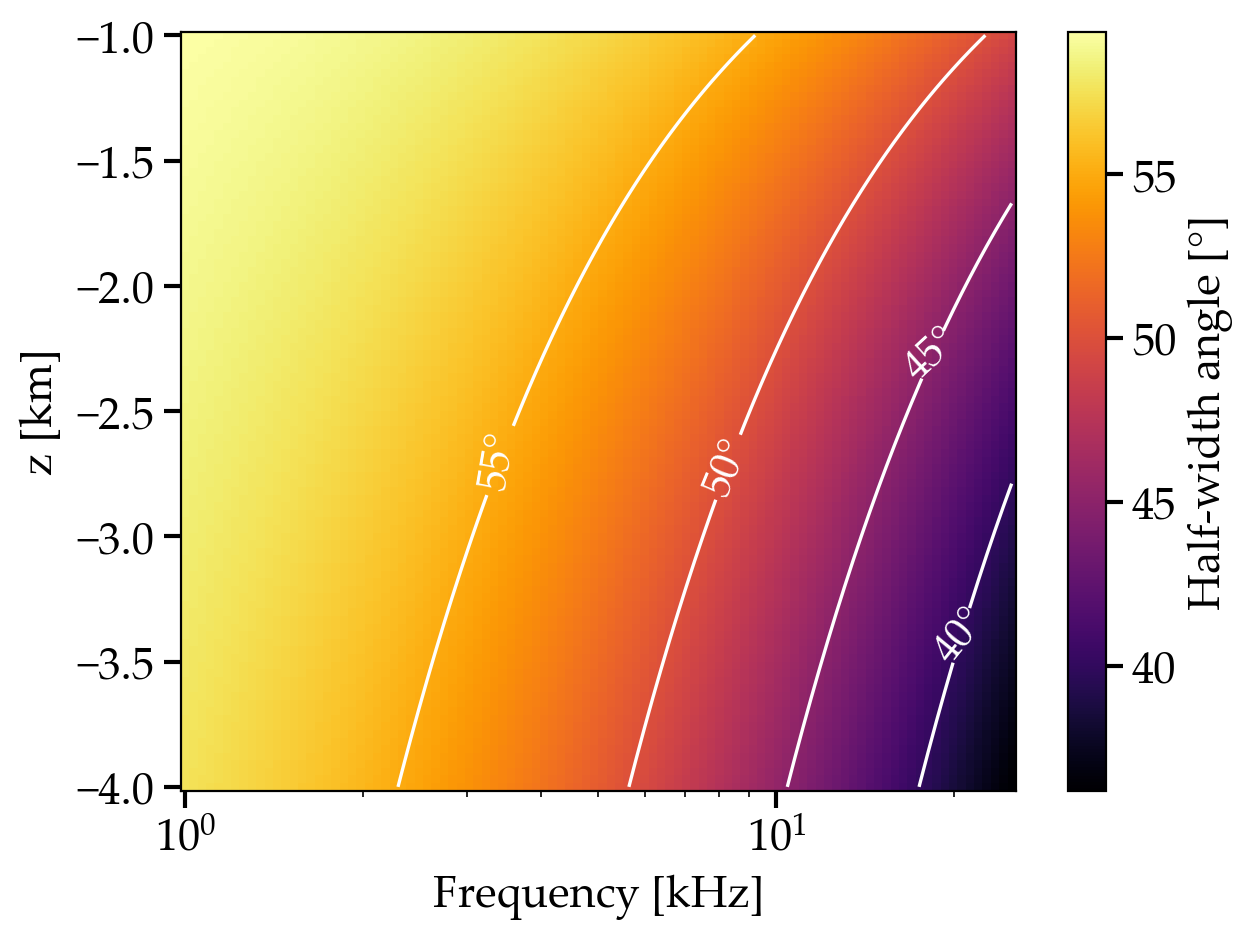

In [11]:
fig, ax = plt.subplots(1, 1, figsize=(6.4, 4.8))

# Plot the pcolormesh
im5 = ax.pcolormesh(f_Hz_plot, z_m_plot, theta_HW_map,
                    shading='auto', cmap='inferno') # ,norm=norm

# Correct colorbar
cb5 = fig.colorbar(im5, ax=ax, label=r"Half-width angle [°]")

# Define and use contour levels consistently
levels_hydro_halfint = [40, 45, 50, 55, 60]
cs5 = ax.contour(f_Hz_plot, z_m_plot, theta_HW_map,
                 levels=levels_hydro_halfint, colors='white', linewidths=1.2)

ax.clabel(cs5, inline=True, fontsize=15, fmt='%1.0f°')

# Axis scaling and labels
ax.set_xscale('log')
ax.set_xlabel("Frequency [kHz]")
ax.set_ylabel(r"z [km]")
# ax.set_title("Constant angle for full power, hydrophone normalised")

plt.tight_layout()
plt.show()

## 2d) $\int F(\theta)$ = 1
In contrast to the plot above, this condition does not check where F reaches half of the peak, but where it reaches the numerical value 1

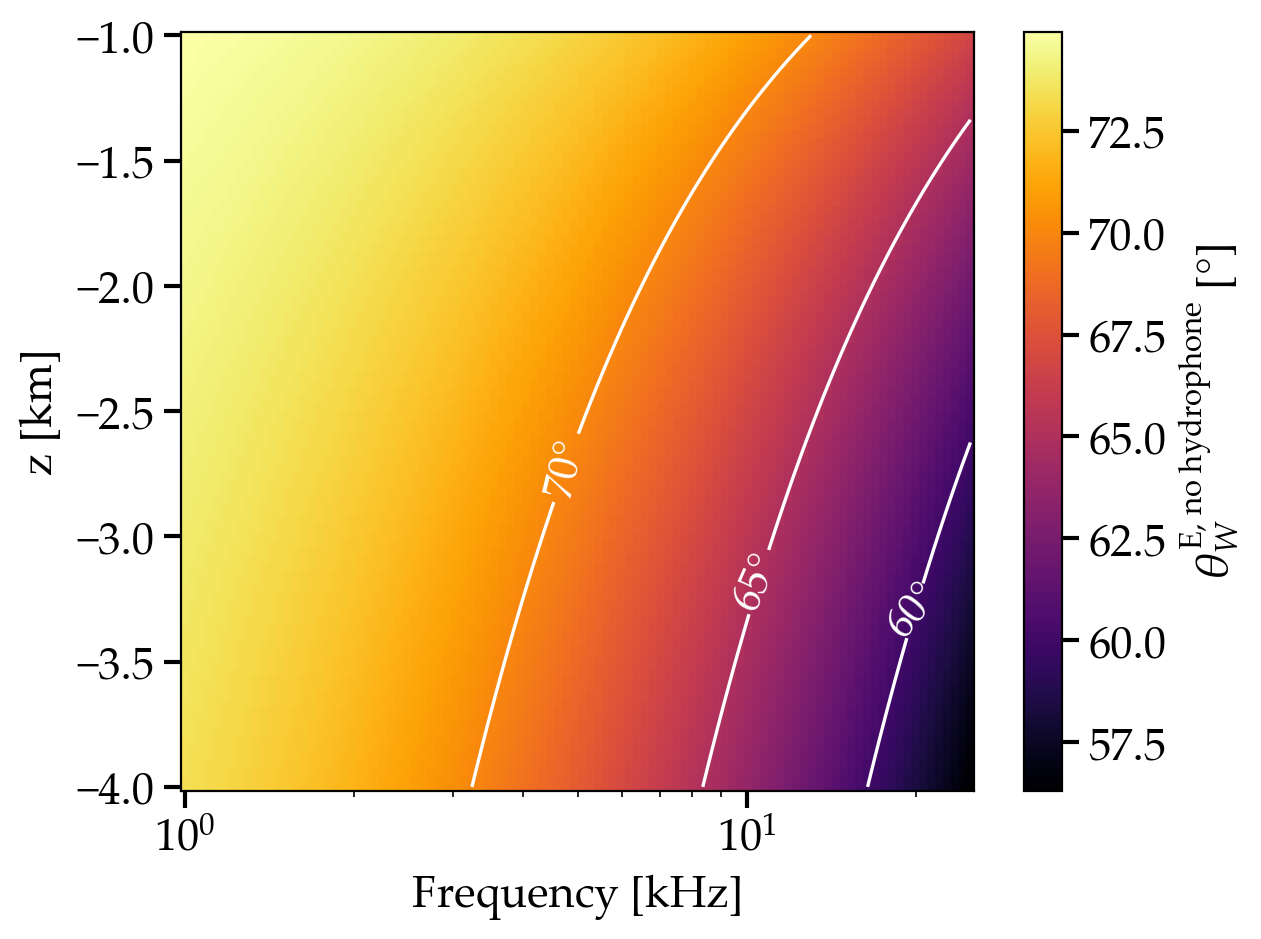

In [12]:
fig, ax = plt.subplots(1, 1, figsize=(6.4, 4.8))

# Plot the pcolormesh
im5 = ax.pcolormesh(f_Hz_plot, z_m_plot, theta_halfint_map,
                    shading='auto', cmap='inferno')

# Correct colorbar
cb5 = fig.colorbar(im5, ax=ax, label=r"$\theta_W^{\text{E, no hydrophone}}$ [°]")

# Define and use contour levels consistently
levels_hydro_halfint = [55, 60, 65, 70, 75]
cs5 = ax.contour(f_Hz_plot, z_m_plot, theta_halfint_map,
                 levels=levels_hydro_halfint, colors='white', linewidths=1.2)

ax.clabel(cs5, inline=True, fontsize=15, fmt='%1.0f°')

# Axis scaling and labels
ax.set_xscale('log')
ax.set_xlabel("Frequency [kHz]")
ax.set_ylabel(r"z [km]")
# ax.set_title("Constant angle for full power, hydrophone normalised")

plt.tight_layout()
plt.show()